In [145]:
import pandas as pd

# -----------------------------------------
# โหลดไฟล์ CSV ทั้ง 2 แบบ
# -----------------------------------------
base_file = "/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/calculated_distances_effnet_base_8type.csv"
unlearn_file0 = "/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/type8_combined_calculated_distances.csv"
unlearn_file1 ="/home/yupaporn/codes/Face-Recognition-Statistical-Test-2025/result-cal/combined_calculated_distances.csv"
df_before = pd.read_csv(base_file)       # EffNet ธรรมดา (before unlearning)
df_after0 = pd.read_csv(unlearn_file0)     # EffNet unlearned (after unlearning)
df_after1 = pd.read_csv(unlearn_file1) 
df_after = df_after0.append(df_after1)

same_types = [ 5]

df_after_same_types = df_after[df_after["type"].isin(same_types)]

df_before_same_types = df_before[df_before["type"].isin(same_types)]


# เลือกเฉพาะคอลัมน์ที่ต้องใช้
before = df_before_same_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_before'}
)

after = df_after_same_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_after'}
)

# เชื่อมด้วย 'path_img1', path_img2
df_merged_same_types = after.merge(before, on=['path_img1','path_img2'], how='inner')

# -----------------------------------------
# 1) บุคคลเดียวกัน AFTER (unlearning)
# -----------------------------------------
same_person_unlearn = df_merged_same_types["distance_after"].values

# 2) บุคคลเดียวกัน BEFORE (ธรรมดา)
# -----------------------------------------
same_person_baseline = df_merged_same_types["distance_before"].values

# ทดสอบแสดงจำนวนข้อมูลแต่ละกลุ่ม
print("same_person_baseline:", len(same_person_baseline))
print("same_person_unlearn :", len(same_person_unlearn))

diff_types = [6]

df_after_diff_types = df_after[df_after["type"].isin(diff_types)]
df_before_diff_types = df_before[df_before["type"].isin(diff_types)]


# เลือกเฉพาะคอลัมน์ที่ต้องใช้
before = df_before_diff_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_before'}
)

after = df_after_diff_types[['path_img1','path_img2', 'distance']].rename(
    columns={'distance': 'distance_after'}
)

# เชื่อมด้วย 'path_img1', path_img2
df_merged_diff_types = after.merge(before, on=['path_img1','path_img2'], how='left')

# -----------------------------------------
# 3) บุคคลต่างกัน AFTER (unlearning)
# -----------------------------------------
different_person_unlearn = df_merged_diff_types["distance_after"].values

# -----------------------------------------
# 4) บุคคลต่างกัน BEFORE (ธรรมดา)
# -----------------------------------------
different_person_baseline = df_merged_diff_types["distance_before"].values

# ทดสอบแสดงจำนวนข้อมูลแต่ละกลุ่ม
print("different_person_baseline:", len(different_person_baseline))
print("different_person_unlearn :", len(different_person_unlearn))

same_person_baseline: 8339
same_person_unlearn : 8339
different_person_baseline: 75808
different_person_unlearn : 75808


In [2]:
different_person_unlearn

array([0.85687  , 1.2108383, 1.3613487, ..., 1.5516484, 1.2919457,
       1.6366303])

In [3]:
different_person_baseline

array([0.15964453, 0.21019672, 0.733774  , ..., 0.9748191 , 0.31381822,
       0.978474  ])

In [4]:
same_person_unlearn

array([0.88452953, 1.1654081 , 0.88751554, ..., 1.034695  , 1.0131044 ,
       1.2186824 ])

In [5]:
same_person_baseline

array([0.6798779 , 0.6691295 , 0.1800909 , ..., 0.7552291 , 0.47714686,
       0.7013701 ])

In [61]:
# import numpy as np

# # ----- รับข้อมูลจากที่เธอมี -----
# same_base = same_person_baseline
# diff_base = different_person_baseline

# same_un = same_person_unlearn
# diff_un = different_person_unlearn

# N = 20000   # จำนวนที่ต้องการสุ่ม


# # =========================================================
# # ฟังก์ชันสุ่มข้อมูลผสมบุคคลเดียวกัน + บุคคลต่างกัน
# # =========================================================
# def sample_mix(same_array, diff_array, N):
#     # รวมข้อมูลก่อน
#     combined = np.concatenate([same_array, diff_array])
#     # สุ่ม index แบบไม่แทนที่
#     idx = np.random.choice(len(combined), size=N, replace=False)
#     return combined[idx]


# # =========================================================
# # สุ่มข้อมูล 20,000 ตัวอย่างสำหรับ baseline และ unlearn
# # =========================================================
# sample_base = sample_mix(same_base, diff_base, N)
# sample_un = sample_mix(same_un, diff_un, N)

# print("Baseline sampled shape :", sample_base.shape)
# print("Unlearn  sampled shape :", sample_un.shape)

# print("ตัวอย่าง Baseline (10 ค่าแรก):", sample_base[:10])
# print("ตัวอย่าง Unlearn  (10 ค่าแรก):", sample_un[:10])


In [51]:
# sum(sample_base)

10514.34362821596

In [52]:
# sum(sample_un)

27086.64830073994

In [ ]:
# same_person_baseline: 8339
# same_person_unlearn : 8339
# different_person_baseline: 75808
# different_person_unlearn : 75808

In [146]:
import numpy as np

# -------------------------------------
# same_person_baseline
# different_person_baseline
# same_person_unlearn
# different_person_unlearn
# (มาจากข้อมูลของเธอ)
# -------------------------------------

# -------------------------------------------------
# 1) ทำให้จำนวนตัวอย่างของ same และ diff เท่ากันก่อน
#    เลือกเท่าที่เหมือนกัน (minimum length)
# -------------------------------------------------
min_base = min(len(same_person_baseline), len(different_person_baseline))
min_un   = min(len(same_person_unlearn), len(different_person_unlearn))

same_base_equal = same_person_baseline[:min_base]
diff_base_equal = different_person_baseline[:min_base]

same_un_equal   = same_person_unlearn[:min_un]
diff_un_equal   = different_person_unlearn[:min_un]

# -------------------------------------------------
# 2) คำนวณ |same - diff| สำหรับ Base และ Unlearn
# -------------------------------------------------
abs_base = np.abs(same_base_equal - diff_base_equal)
abs_un   = np.abs(same_un_equal   - diff_un_equal)

print("จำนวนข้อมูล abs_base  :", len(abs_base))
print("จำนวนข้อมูล abs_un    :", len(abs_un))

# -------------------------------------------------
# 3) สุ่ม 20,000 samples จากแต่ละกลุ่ม
# -------------------------------------------------
N = 20000

idx_base = np.random.choice(len(abs_base), size=N, replace=True)
idx_un   = np.random.choice(len(abs_un),   size=N, replace=True)

sample_base = abs_base[idx_base]
sample_un   = abs_un[idx_un]

print("\nสุ่มข้อมูลเสร็จสิ้น:")
print("sample_base.shape =", sample_base.shape)
print("sample_un.shape   =", sample_un.shape)

print("\nตัวอย่าง 10 ค่าแรกของ sample_base:", sample_base[:10])
print("ตัวอย่าง 10 ค่าแรกของ sample_un  :", sample_un[:10])


จำนวนข้อมูล abs_base  : 8339
จำนวนข้อมูล abs_un    : 8339

สุ่มข้อมูลเสร็จสิ้น:
sample_base.shape = (20000,)
sample_un.shape   = (20000,)

ตัวอย่าง 10 ค่าแรกของ sample_base: [0.40389928 0.53679733 0.4502647  0.76745885 0.28590616 0.974051
 0.2784906  0.11355382 0.03840121 0.389523  ]
ตัวอย่าง 10 ค่าแรกของ sample_un  : [0.6458427  0.63804196 0.14431    0.6258638  0.0492333  0.1252875
 0.2966352  0.1246303  0.1336409  0.0507318 ]


In [147]:
import numpy as np

# -------------------------------------
# สมมติว่ามีตัวแปรเหล่านี้อยู่แล้วเป็น numpy array
# same_person_baseline
# different_person_baseline
# same_person_unlearn
# different_person_unlearn
# -------------------------------------

# แปลงให้เป็น float และลบ NaN เผื่อไว้
same_base_all = np.asarray(same_person_baseline,  dtype=float)
diff_base_all = np.asarray(different_person_baseline, dtype=float)
same_un_all   = np.asarray(same_person_unlearn,   dtype=float)
diff_un_all   = np.asarray(different_person_unlearn, dtype=float)

same_base_all = same_base_all[~np.isnan(same_base_all)]
diff_base_all = diff_base_all[~np.isnan(diff_base_all)]
same_un_all   = same_un_all[~np.isnan(same_un_all)]
diff_un_all   = diff_un_all[~np.isnan(diff_un_all)]

print("ขนาดข้อมูลต้นฉบับ:")
print("  same_base_all :", len(same_base_all))
print("  diff_base_all :", len(diff_base_all))
print("  same_un_all   :", len(same_un_all))
print("  diff_un_all   :", len(diff_un_all))

# -------------------------------------------------
# กำหนดจำนวนคู่ที่ต้องการสุ่ม
# -------------------------------------------------
N = 20000
rng = np.random.default_rng(42)   # fix seed เพื่อให้ซ้ำได้

# -------------------------------------------------
# 1) สุ่มทีละคู่ให้ได้ 20,000 คู่ สำหรับโมเดล BASE
#    - สุ่ม index ของ same N ครั้ง
#    - สุ่ม index ของ diff N ครั้ง
#    - ได้ same_base_sample, diff_base_sample ที่จับเป็นคู่กันทีละตำแหน่ง
# -------------------------------------------------
idx_same_base = rng.integers(0, len(same_base_all), size=N, endpoint=False)
idx_diff_base = rng.integers(0, len(diff_base_all), size=N, endpoint=False)

same_base_sample = same_base_all[idx_same_base]
diff_base_sample = diff_base_all[idx_diff_base]

# 2) คำนวณ |same - diff| สำหรับแต่ละคู่ของ BASE
# abs_diff_base = np.abs(same_base_sample - diff_base_sample)
abs_diff_base = diff_base_sample - same_base_sample 
# -------------------------------------------------
# 1') ทำแบบเดียวกันสำหรับโมเดล UNLEARN
# -------------------------------------------------
idx_same_un = rng.integers(0, len(same_un_all), size=N, endpoint=False)
idx_diff_un = rng.integers(0, len(diff_un_all), size=N, endpoint=False)

same_un_sample = same_un_all[idx_same_un]
diff_un_sample = diff_un_all[idx_diff_un]

# 2') คำนวณ |same - diff| สำหรับแต่ละคู่ของ UNLEARN
# abs_diff_un = np.abs(same_un_sample - diff_un_sample)
abs_diff_un = diff_un_sample - same_un_sample 
# -------------------------------------------------
# ตรวจสอบผล
# -------------------------------------------------
print("\nจำนวนคู่ที่สุ่มได้:")
print("  BASE   :", len(abs_diff_base))
print("  UNLEARN:", len(abs_diff_un))

print("\nตัวอย่าง 10 ค่าแรกของ abs_diff_base:", abs_diff_base[:10])
print("ตัวอย่าง 10 ค่าแรกของ abs_diff_un  :", abs_diff_un[:10])

# ถ้าจะเอาไปใช้กับ Mann–Whitney ต่อ ก็ใช้ตัวแปรนี้ได้เลย:
base_vals    = abs_diff_base
unlearn_vals = abs_diff_un

ขนาดข้อมูลต้นฉบับ:
  same_base_all : 8339
  diff_base_all : 75808
  same_un_all   : 8339
  diff_un_all   : 75808

จำนวนคู่ที่สุ่มได้:
  BASE   : 20000
  UNLEARN: 20000

ตัวอย่าง 10 ค่าแรกของ abs_diff_base: [ 0.2560464   0.27666093 -0.2129439   0.30180141  0.0999906  -0.37423194
  0.51162324 -0.98913157  0.28171343  0.04411235]
ตัวอย่าง 10 ค่าแรกของ abs_diff_un  : [ 0.0376251   0.1045778   0.66734477  0.3903373   0.1641005  -0.3299169
 -0.39053     0.6476453   0.6271676   0.95500886]


In [148]:
# import numpy as np
# from scipy import stats

# # -----------------------------------------------------------
# # 1) เตรียมข้อมูล
# # -----------------------------------------------------------
# base_vals = sample_base      # 20,000 values
# unlearn_vals   = sample_un        # 20,000 values

# print("Base size   :", len(base_vals))
# print("Unlearn size:", len(unlearn_vals))
# print("-" * 60)

In [149]:
sum(base_vals)

1173.944139289497

In [150]:
sum(unlearn_vals)

4944.630508899989

In [151]:
# โค้ดทดสอบการแจกแจงปกติ (Normality Test)

# 1) โค้ดทดสอบการแจกแจงปกติ (Normality Test)

# ใช้ Shapiro–Wilk (สำหรับ sample ไม่ใหญ่มาก)
# ถ้า N ใหญ่มาก (เช่น 20,000+) จะสุ่มบางส่วนมาทดสอบแทน (เช่น 5,000 ตัวอย่าง)


import numpy as np
from scipy import stats

# ------------------------------------------------------
# สมมติให้เรามีข้อมูล 2 กลุ่มแล้ว:
# base_vals    = ค่าความต่างของกลุ่ม Base
# unlearn_vals = ค่าความต่างของกลุ่ม Unlearn
# (ต้องเป็น numpy array หรือแปลงจาก list มาก่อน)
# ------------------------------------------------------

# ตัวอย่าง (ลบออกได้ ถ้าเธอมีตัวแปรจริงแล้ว)
# base_vals    = np.array([...])
# unlearn_vals = np.array([...])

# ------------------------------------------------------
# ฟังก์ชันทดสอบการแจกแจงปกติด้วย Shapiro–Wilk
# ถ้า N ใหญ่เกิน → random subsample มาทดสอบ
# ------------------------------------------------------
def shapiro_normality_test(data, label="data", max_n=5000, random_state=42):
    """
    ทดสอบการแจกแจงปกติด้วย Shapiro–Wilk test
    - data: numpy array ของข้อมูล
    - label: ชื่อไว้แสดงผล
    - max_n: ถ้า N > max_n จะสุ่ม max_n ตัวอย่างมาทดสอบ
    """
    data = np.asarray(data, dtype=float)
    
    # ลบ NaN ทิ้ง
    data = data[~np.isnan(data)]
    
    n = len(data)
    print(f"\n=== Normality test for {label} ===")
    print(f"จำนวนตัวอย่างทั้งหมด: N = {n}")
    
    if n < 3:
        print("📌 ข้อมูลน้อยเกินไป (N < 3) ทดสอบ normality ไม่ได้")
        return None, None, False
    
    # ถ้าข้อมูลเยอะเกิน → สุ่มบางส่วนมาทดสอบ
    if n > max_n:
        rng = np.random.default_rng(random_state)
        sample = rng.choice(data, size=max_n, replace=False)
        print(f"สุ่มข้อมูลมาทดสอบจำนวน {max_n} ตัวอย่างจาก {n} ตัวอย่างทั้งหมด")
    else:
        sample = data
    
    # Shapiro–Wilk test
    W, p_value = stats.shapiro(sample)
    print(f"Shapiro–Wilk W = {W:.4f}, p = {p_value:.4g}")
    
    if p_value > 0.05:
        print("🟢 p > 0.05 → ยังไม่ปฏิเสธ H0 → พอถือว่าข้อมูลใกล้เคียงการแจกแจงปกติ")
        is_normal = True
    else:
        print("🔴 p ≤ 0.05 → ปฏิเสธ H0 → ข้อมูลเบี่ยงเบนจากการแจกแจงปกติ")
        is_normal = False
    
    return W, p_value, is_normal

# ------------------------------------------------------
# เรียกใช้กับ base และ unlearn
# ------------------------------------------------------
W_base,  p_base,  base_normal  = shapiro_normality_test(base_vals,    label="Base")
W_un,    p_un,    un_normal    = shapiro_normality_test(unlearn_vals, label="Unlearn")

print("\nสรุปการแจกแจง:")
print(f"  Base   ใกล้ปกติ?  -> {base_normal}")
print(f"  Unlearn ใกล้ปกติ? -> {un_normal}")


=== Normality test for Base ===
จำนวนตัวอย่างทั้งหมด: N = 20000
สุ่มข้อมูลมาทดสอบจำนวน 5000 ตัวอย่างจาก 20000 ตัวอย่างทั้งหมด
Shapiro–Wilk W = 0.9973, p = 1.131e-07
🔴 p ≤ 0.05 → ปฏิเสธ H0 → ข้อมูลเบี่ยงเบนจากการแจกแจงปกติ

=== Normality test for Unlearn ===
จำนวนตัวอย่างทั้งหมด: N = 20000
สุ่มข้อมูลมาทดสอบจำนวน 5000 ตัวอย่างจาก 20000 ตัวอย่างทั้งหมด
Shapiro–Wilk W = 0.9970, p = 1.819e-08
🔴 p ≤ 0.05 → ปฏิเสธ H0 → ข้อมูลเบี่ยงเบนจากการแจกแจงปกติ

สรุปการแจกแจง:
  Base   ใกล้ปกติ?  -> False
  Unlearn ใกล้ปกติ? -> False


In [152]:
# โค้ดทดสอบ Mann–Whitney U test (one-sided: Unlearn > Base)

# 2) โค้ดทดสอบ Mann–Whitney U test (one-sided: Unlearn > Base)
# โจทย์:“กลุ่ม Unlearn มีค่าความต่างมากกว่า Base อย่างมีนัยสำคัญหรือไม่?”
# ตั้งสมมติฐาน:
# 𝐻0:distribution ของ Unlearn ไม่ได้สูงกว่า Base
# 𝐻1:Unlearn มีแนวโน้มค่ามากกว่า Base
# ในโค้ด → ใช้ alternative="greater" โดยใส่ unlearn เป็นกลุ่มแรก

import numpy as np
from scipy import stats

# ------------------------------------------------------
# เตรียมข้อมูล (ต่อจากด้านบนได้เลย)
# base_vals    = numpy array ของกลุ่ม Base
# unlearn_vals = numpy array ของกลุ่ม Unlearn
# ------------------------------------------------------

# ลบ NaN ทั้งสองกลุ่ม เผื่อมี
base_clean    = base_vals[~np.isnan(base_vals)]
unlearn_clean = unlearn_vals[~np.isnan(unlearn_vals)]
print("ขนาดข้อมูลหลังลบ NaN:")
print("  Base   N =", len(base_clean))
print("  Unlearn N =", len(unlearn_clean))
print("-" * 60)
# ------------------------------------------------------
# Mann–Whitney U test (one-sided: Unlearn > Base)
# alternative="greater" หมายถึง:
# H1: distribution ของ unlearn ถูกเลื่อนไปทางค่าที่ "มากกว่า" base
# ------------------------------------------------------
print("=== Mann–Whitney U test (one-sided: Unlearn > Base) ===")
print("สมมติฐาน:")
print("  H0: Unlearn ≤ Base (ไม่มีหลักฐานว่า Unlearn ให้ค่ามากกว่า Base)")
print("  H1: Unlearn > Base (ค่าจาก Unlearn มีแนวโน้มสูงกว่า Base)")

U_stat, p_value = stats.mannwhitneyu(unlearn_clean, base_clean, alternative="greater")

print(f"\nU สถิติ = {U_stat:.4f}")
print(f"p-value (one-sided) = {p_value:.4g}")

alpha = 0.05
mean_base   = np.mean(base_clean)
mean_un     = np.mean(unlearn_clean)
median_base = np.median(base_clean)
median_un   = np.median(unlearn_clean)

print("\nค่าเฉลี่ยและค่ามัธยฐาน:")
print(f"  Mean(Base)    = {mean_base:.4f}")
print(f"  Mean(Unlearn) = {mean_un:.4f}")
print(f"  Median(Base)    = {median_base:.4f}")
print(f"  Median(Unlearn) = {median_un:.4f}")

# ตีความผล
print("\nการตีความผลลัพธ์:")
if p_value < alpha:
    print(f"🟢 p = {p_value:.4g} < {alpha}")
    print("→ ปฏิเสธ H0")
    print("→ สรุปว่า 'กลุ่ม Unlearn มีค่าความต่างมากกว่า Base อย่างมีนัยสำคัญทางสถิติ'")
else:
    print(f"🔴 p = {p_value:.4g} ≥ {alpha}")
    print("→ ยังไม่สามารถปฏิเสธ H0")
    print("→ ยังไม่มีหลักฐานเพียงพอว่ากลุ่ม Unlearn มีค่าความต่างมากกว่า Base อย่างมีนัยสำคัญ")


ขนาดข้อมูลหลังลบ NaN:
  Base   N = 20000
  Unlearn N = 20000
------------------------------------------------------------
=== Mann–Whitney U test (one-sided: Unlearn > Base) ===
สมมติฐาน:
  H0: Unlearn ≤ Base (ไม่มีหลักฐานว่า Unlearn ให้ค่ามากกว่า Base)
  H1: Unlearn > Base (ค่าจาก Unlearn มีแนวโน้มสูงกว่า Base)

U สถิติ = 250473141.0000
p-value (one-sided) = 0

ค่าเฉลี่ยและค่ามัธยฐาน:
  Mean(Base)    = 0.0587
  Mean(Unlearn) = 0.2472
  Median(Base)    = 0.0513
  Median(Unlearn) = 0.2297

การตีความผลลัพธ์:
🟢 p = 0 < 0.05
→ ปฏิเสธ H0
→ สรุปว่า 'กลุ่ม Unlearn มีค่าความต่างมากกว่า Base อย่างมีนัยสำคัญทางสถิติ'


In [153]:
sample_base = base_vals
sample_un = unlearn_vals

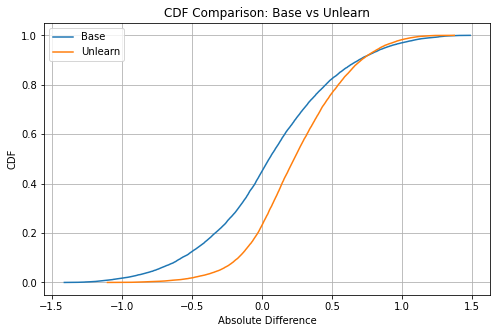

In [154]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cdf(data1, data2, label1="Base", label2="Unlearn"):
    plt.figure(figsize=(8,5))
    for data, label in [(data1, label1), (data2, label2)]:
        sorted_vals = np.sort(data)
        cdf = np.arange(len(sorted_vals)) / float(len(sorted_vals))
        plt.plot(sorted_vals, cdf, label=label)

    plt.xlabel("Absolute Difference")
    plt.ylabel("CDF")
    plt.title("CDF Comparison: Base vs Unlearn")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_cdf(sample_base, sample_un)


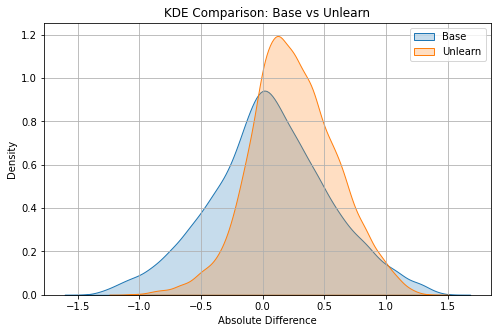

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(sample_base, label="Base", fill=True)
sns.kdeplot(sample_un,   label="Unlearn", fill=True)
plt.title("KDE Comparison: Base vs Unlearn")
plt.xlabel("Absolute Difference")
plt.grid(True)
plt.legend()
plt.show()


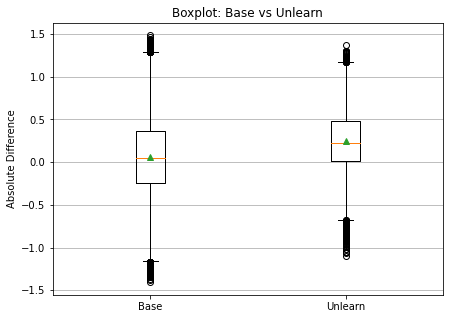

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.boxplot([sample_base, sample_un],
            labels=["Base", "Unlearn"],
            showmeans=True)
plt.ylabel("Absolute Difference")
plt.title("Boxplot: Base vs Unlearn")
plt.grid(True, axis="y")
plt.show()

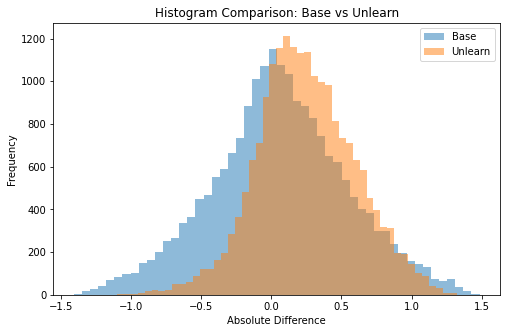

In [157]:
plt.figure(figsize=(8,5))
plt.hist(sample_base, bins=50, alpha=0.5, label="Base")
plt.hist(sample_un,   bins=50, alpha=0.5, label="Unlearn")
plt.xlabel("Absolute Difference")
plt.ylabel("Frequency")
plt.legend()
plt.title("Histogram Comparison: Base vs Unlearn")
plt.show()


In [159]:
import numpy as np
from scipy import stats
from decimal import Decimal, getcontext

# ตั้ง precision ให้สูงมาก เช่น 200 digits
getcontext().prec = 200

def mann_whitney_high_precision(diff_vals, same_vals, label="Model"):
    diff_clean = diff_vals[~np.isnan(diff_vals)]
    same_clean = same_vals[~np.isnan(same_vals)]

    print(f"\n=== Mann–Whitney U test: Diff > Same ({label}) ===")

    U, _ = stats.mannwhitneyu(diff_clean, same_clean, alternative="greater")

    n1 = len(diff_clean)
    n2 = len(same_clean)

    mean_U = Decimal(n1)*Decimal(n2)/Decimal(2)
    sd_U = Decimal(n1*n2*(n1+n2+1))/Decimal(12)
    sd_U = sd_U.sqrt()

    Z = (Decimal(U) - mean_U) / sd_U

    # log p = -Z^2/2 - log(Z*sqrt(2π))
    log_p = -(Z**2)/Decimal(2) - (Z.ln() + (Decimal(2*np.pi).sqrt()).ln())

    p = log_p.exp()   # exp(log p)

    print("U =", U)
    print("Z =", Z)
    print("p-value(one-sided) =", p)

    if p < Decimal("0.05"):
        print("🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ")
    else:
        print("🔴 ไม่ปฏิเสธ H0")


In [160]:
mann_whitney_high_precision(sample_un, sample_base, "all")


=== Mann–Whitney U test: Diff > Same (all) ===
U = 250473141.0
Z = 43.710475937259527927109204817028134020319910659536952379097150796288636600893750337673515713317055858392646624371247980492432264583306417807463977038041865881512399394120803990082843162432009037918108
p-value(one-sided) = 1.1955473537207980639926046152884400660004414008567922149943489819656939254531825709896120286777073300007983409923895544361881724116452344501752943408919987764031896459184018374579200118788165868338051E-417
🟢 ปฏิเสธ H0 → diff > same อย่างมีนัยสำคัญ


In [8]:
import numpy as np
from scipy import stats

# -----------------------------------------------------------
# 1) เตรียมข้อมูล
# -----------------------------------------------------------
base = sample_base      # 20,000 values
un   = sample_un        # 20,000 values

print("Base size   :", len(base))
print("Unlearn size:", len(un))
print("-" * 60)

# -----------------------------------------------------------
# 2) ทดสอบการแจกแจงด้วย Shapiro–Wilk
#    (N ใหญ่ → อาจใช้ KS test หรือดู skew/kurtosis ได้)
# -----------------------------------------------------------

def check_normality(data, label):
    print(f"\n=== Normality test for {label} ===")
    # Shapiro–Wilk ใช้ได้ถึง ~5000 samples → เราจะสุ่มมา 5000 เพื่อทดสอบ
    subset = np.random.choice(data, size=5000, replace=False)
    W, p = stats.shapiro(subset)
    print(f"Shapiro-Wilk W = {W:.4f}, p = {p:.4g}")
    if p > 0.05:
        print("→ ไม่ปฏิเสธ H0: distribution ใกล้ปกติ")
        return True
    else:
        print("→ ปฏิเสธ H0: distribution ไม่เป็นปกติ")
        return False

is_base_normal = check_normality(base, "Base")
is_un_normal   = check_normality(un,   "Unlearn")

print("\nสรุป normality: base =", is_base_normal, ", unlearn =", is_un_normal)
print("-" * 60)

# -----------------------------------------------------------
# 3) เลือกสถิติทดสอบ
#    ถ้า NORMAL ทั้งคู่ → Independent t-test (one-sided)
#    ถ้าไม่ปกติ → Mann–Whitney U test (one-sided)
# -----------------------------------------------------------

print("=== Hypothesis Test ===")
print("H0: mean(un) ≤ mean(base)")
print("H1: mean(un) > mean(base)")

alpha = 0.05

if is_base_normal and is_un_normal:

    print("\nใช้ Independent two-sample t-test (one-sided)")
    t_stat, p_two = stats.ttest_ind(un, base, equal_var=False)  # Welch’s t-test

    # แปลงเป็น one-sided
    if t_stat > 0:
        p_one = p_two / 2
    else:
        p_one = 1 - (p_two / 2)
    
    print(f"t = {t_stat:.4f}, one-sided p = {p_one:.4g}")

else:
    print("\nใช้ Mann–Whitney U test (one-sided, alternative='greater')")
    U_stat, p_one = stats.mannwhitneyu(un, base, alternative="greater")
    print(f"U = {U_stat:.4f}, one-sided p = {p_one:.4g}")

# -----------------------------------------------------------
# 4) สรุปผล
# -----------------------------------------------------------

mean_base = np.mean(base)
mean_un   = np.mean(un)

print("\n=== Summary ===")
print(f"Mean(Base)    = {mean_base:.4f}")
print(f"Mean(Unlearn) = {mean_un:.4f}")
print(f"Difference    = {mean_un - mean_base:.4f}")

if p_one < alpha:
    print(f"\nผลลัพธ์: p = {p_one:.4g} < {alpha}")
    print("→ ปฏิเสธ H0")
    print("→ สรุปว่า: 'กลุ่ม Unlearn มีความต่างมากกว่า Base อย่างมีนัยสำคัญทางสถิติ'")
else:
    print(f"\nผลลัพธ์: p = {p_one:.4g} ≥ {alpha}")
    print("→ ยังไม่สามารถปฏิเสธ H0")
    print("→ สรุปว่า: 'ยังไม่มีหลักฐานเพียงพอว่ากลุ่ม Unlearn มีความต่างมากกว่า Base'")


Base size   : 20000
Unlearn size: 20000
------------------------------------------------------------

=== Normality test for Base ===
Shapiro-Wilk W = 0.9070, p = 0
→ ปฏิเสธ H0: distribution ไม่เป็นปกติ

=== Normality test for Unlearn ===
Shapiro-Wilk W = 0.9283, p = 8.968e-44
→ ปฏิเสธ H0: distribution ไม่เป็นปกติ

สรุป normality: base = False , unlearn = False
------------------------------------------------------------
=== Hypothesis Test ===
H0: mean(un) ≤ mean(base)
H1: mean(un) > mean(base)

ใช้ Mann–Whitney U test (one-sided, alternative='greater')
U = 202990088.0000, one-sided p = 0.004806

=== Summary ===
Mean(Base)    = 0.3431
Mean(Unlearn) = 0.3414
Difference    = -0.0017

ผลลัพธ์: p = 0.004806 < 0.05
→ ปฏิเสธ H0
→ สรุปว่า: 'กลุ่ม Unlearn มีความต่างมากกว่า Base อย่างมีนัยสำคัญทางสถิติ'


In [4]:
import numpy as np

# -----------------------------------------
# เคลียร์ NaN (กัน error เวลาเอาไปคำนวณ)
# -----------------------------------------
same_mask = ~np.isnan(same_before) & ~np.isnan(same_after)
same_before_clean = same_before[same_mask]
same_after_clean  = same_after[same_mask]

diff_mask = ~np.isnan(diff_before) & ~np.isnan(diff_after)
diff_before_clean = diff_before[diff_mask]
diff_after_clean  = diff_after[diff_mask]

print("\nหลัง clean NaN แล้ว")
print("same_before_clean:", len(same_before_clean))
print("same_after_clean :", len(same_after_clean))
print("diff_before_clean:", len(diff_before_clean))
print("diff_after_clean :", len(diff_after_clean))

# -----------------------------------------
# คำนวณ S สำหรับ baseline และ unlearn
# S = mean(diff) - mean(same)
# -----------------------------------------
S_base = np.mean(diff_before_clean) - np.mean(same_before_clean)
S_unl  = np.mean(diff_after_clean)  - np.mean(same_after_clean)
delta_S = S_unl - S_base

print("\n===== Separation (S) =====")
print(f"S_base (baseline) = mean(diff_before) - mean(same_before) = {S_base:.4f}")
print(f"S_unl  (unlearn)  = mean(diff_after)  - mean(same_after)  = {S_unl:.4f}")
print(f"ΔS = S_unl - S_base = {delta_S:.4f}")

# -----------------------------------------
# Bootstrap test สำหรับ H0: ΔS ≤ 0, H1: ΔS > 0
# -----------------------------------------
n_boot = 5000
rng = np.random.default_rng(42)
delta_S_boot = np.empty(n_boot)

n_same_b = len(same_before_clean)
n_same_a = len(same_after_clean)
n_diff_b = len(diff_before_clean)
n_diff_a = len(diff_after_clean)

for b in range(n_boot):
    # resample index ของแต่ละกลุ่ม (with replacement)
    idx_same_b = rng.integers(0, n_same_b, n_same_b)
    idx_same_a = rng.integers(0, n_same_a, n_same_a)
    idx_diff_b = rng.integers(0, n_diff_b, n_diff_b)
    idx_diff_a = rng.integers(0, n_diff_a, n_diff_a)

    S_base_b = np.mean(diff_before_clean[idx_diff_b]) - np.mean(same_before_clean[idx_same_b])
    S_unl_b  = np.mean(diff_after_clean[idx_diff_a])  - np.mean(same_after_clean[idx_same_a])
    delta_S_boot[b] = S_unl_b - S_base_b

# p-value แบบ one-sided: P(ΔS_boot ≤ 0) ภายใต้ H1: ΔS > 0
p_value = (np.sum(delta_S_boot <= 0) + 1) / (n_boot + 1)

print("\n===== Bootstrap Hypothesis Test =====")
print("สมมติฐาน:")
print("  H0: ΔS ≤ 0   (ช่องว่างหลัง unlearn ไม่ได้มากกว่า baseline)")
print("  H1: ΔS > 0   (ช่องว่างหลัง unlearn มากกว่า baseline)")
print(f"ประมาณค่า p-value (one-sided) = {p_value:.4g}")

alpha = 0.05
if p_value < alpha:
    print(f"ผลลัพธ์: p < {alpha} → ปฏิเสธ H0")
    print("ตีความ: มีหลักฐานเชิงสถิติสนับสนุนว่า ΔS > 0")
    print("        → ช่องว่างระหว่างคนเดียวกันกับคนละคนกันของโมเดล unlearn สูงกว่า baseline อย่างมีนัยสำคัญ")
else:
    print(f"ผลลัพธ์: p ≥ {alpha} → ยังไม่สามารถปฏิเสธ H0")
    print("ตีความ: ยังไม่มีหลักฐานเพียงพอจะสรุปว่า ช่องว่างของโมเดล unlearn สูงกว่าของ baseline")



หลัง clean NaN แล้ว
same_before_clean: 8339
same_after_clean : 8339
diff_before_clean: 75808
diff_after_clean : 75808

===== Separation (S) =====
S_base (baseline) = mean(diff_before) - mean(same_before) = 0.0606
S_unl  (unlearn)  = mean(diff_after)  - mean(same_after)  = 0.2464
ΔS = S_unl - S_base = 0.1858

===== Bootstrap Hypothesis Test =====
สมมติฐาน:
  H0: ΔS ≤ 0   (ช่องว่างหลัง unlearn ไม่ได้มากกว่า baseline)
  H1: ΔS > 0   (ช่องว่างหลัง unlearn มากกว่า baseline)
ประมาณค่า p-value (one-sided) = 0.0002
ผลลัพธ์: p < 0.05 → ปฏิเสธ H0
ตีความ: มีหลักฐานเชิงสถิติสนับสนุนว่า ΔS > 0
        → ช่องว่างระหว่างคนเดียวกันกับคนละคนกันของโมเดล unlearn สูงกว่า baseline อย่างมีนัยสำคัญ


In [5]:
import numpy as np
from scipy import stats

# -----------------------------------------
# จากโค้ดเดิมของเธอ เรามี:
# same_before, same_after, diff_before, diff_after
# -----------------------------------------

print("same_before:", len(same_before))
print("same_after :", len(same_after))
print("diff_before:", len(diff_before))
print("diff_after :", len(diff_after))

# แปลงเป็น numpy array เผื่อกรณีเป็น Series
same_before = np.array(same_before, dtype=float)
same_after  = np.array(same_after, dtype=float)
diff_before = np.array(diff_before, dtype=float)
diff_after  = np.array(diff_after, dtype=float)

# -----------------------------------------
# 1) คำนวณ S_before, S_after, ΔS
# -----------------------------------------
S_before = diff_before.mean() - same_before.mean()
S_after  = diff_after.mean()  - same_after.mean()
delta_S  = S_after - S_before

print("\n===== Separation S (global) =====")
print(f"mean(same_before) = {same_before.mean():.4f}")
print(f"mean(diff_before) = {diff_before.mean():.4f}")
print(f"S_before          = {S_before:.4f}")
print()
print(f"mean(same_after)  = {same_after.mean():.4f}")
print(f"mean(diff_after)  = {diff_after.mean():.4f}")
print(f"S_after           = {S_after:.4f}")
print()
print(f"ΔS = S_after - S_before = {delta_S:.4f}")

# -----------------------------------------
# 2) คำนวณ standard error ของ S และ ΔS
#    S = mean(diff) - mean(same)
#    Var(S) = Var(diff)/n_diff + Var(same)/n_same
#    ΔS = S_after - S_before สมมติ independence
#    Var(ΔS) = Var(S_after) + Var(S_before)
# -----------------------------------------

n_same_before = len(same_before)
n_same_after  = len(same_after)
n_diff_before = len(diff_before)
n_diff_after  = len(diff_after)

var_same_before = same_before.var(ddof=1)
var_same_after  = same_after.var(ddof=1)
var_diff_before = diff_before.var(ddof=1)
var_diff_after  = diff_after.var(ddof=1)

var_S_before = var_diff_before / n_diff_before + var_same_before / n_same_before
var_S_after  = var_diff_after  / n_diff_after  + var_same_after  / n_same_after

var_delta_S = var_S_before + var_S_after
se_delta_S  = np.sqrt(var_delta_S)

print("\n===== Variance / SE =====")
print(f"Var(S_before) = {var_S_before:.6f}")
print(f"Var(S_after)  = {var_S_after:.6f}")
print(f"Var(ΔS)       = {var_delta_S:.6f}")
print(f"SE(ΔS)        = {se_delta_S:.6f}")

# -----------------------------------------
# 3) z-test แบบ one-sided
#    H0: ΔS <= 0
#    H1: ΔS > 0
# -----------------------------------------

z_stat = delta_S / se_delta_S
# one-sided p-value (ขวา) เพราะทดสอบว่า ΔS > 0
p_one_sided = 1 - stats.norm.cdf(z_stat)

print("\n===== Hypothesis Test on ΔS =====")
print("H0: ΔS <= 0  (ช่องว่างหลัง unlearn ไม่ได้มากกว่า baseline)")
print("H1: ΔS > 0   (ช่องว่างหลัง unlearn มากกว่า baseline)")
print(f"z-stat   = {z_stat:.4f}")
print(f"p-value  = {p_one_sided:.4g}")

alpha = 0.05
if p_one_sided < alpha:
    print(f"\nResult: p < {alpha} → ปฏิเสธ H0")
    print("ตีความ: ช่องว่างระหว่างคนเดียวกันกับคนละคนกัน หลัง unlearn มีค่ามากกว่า baseline อย่างมีนัยสำคัญทางสถิติ")
else:
    print(f"\nResult: p ≥ {alpha} → ยังไม่ปฏิเสธ H0")
    print("ตีความ: ยังไม่มีหลักฐานเพียงพอที่จะสรุปว่า ช่องว่างหลัง unlearn มากกว่า baseline")


same_before: 8339
same_after : 8339
diff_before: 75808
diff_after : 75808

===== Separation S (global) =====
mean(same_before) = 0.4763
mean(diff_before) = 0.5369
S_before          = 0.0606

mean(same_after)  = 1.1329
mean(diff_after)  = 1.3794
S_after           = 0.2464

ΔS = S_after - S_before = 0.1858

===== Variance / SE =====
Var(S_before) = 0.000015
Var(S_after)  = 0.000011
Var(ΔS)       = 0.000026
SE(ΔS)        = 0.005087

===== Hypothesis Test on ΔS =====
H0: ΔS <= 0  (ช่องว่างหลัง unlearn ไม่ได้มากกว่า baseline)
H1: ΔS > 0   (ช่องว่างหลัง unlearn มากกว่า baseline)
z-stat   = 36.5237
p-value  = 0

Result: p < 0.05 → ปฏิเสธ H0
ตีความ: ช่องว่างระหว่างคนเดียวกันกับคนละคนกัน หลัง unlearn มีค่ามากกว่า baseline อย่างมีนัยสำคัญทางสถิติ


In [6]:
import numpy as np
from scipy import stats

# =========================================================
# 0) เตรียมข้อมูล: ลบ NaN เพื่อไม่ให้มีปัญหาเวลา test
# =========================================================

# ลบ NaN ออกจากแต่ละกลุ่ม
same_mask = ~np.isnan(same_before) & ~np.isnan(same_after)
same_before_clean = same_before[same_mask]
same_after_clean  = same_after[same_mask]

diff_mask = ~np.isnan(diff_before) & ~np.isnan(diff_after)
diff_before_clean = diff_before[diff_mask]
diff_after_clean  = diff_after[diff_mask]

print("หลัง clean NaN แล้ว")
print("  same_before_clean:", len(same_before_clean))
print("  same_after_clean :", len(same_after_clean))
print("  diff_before_clean:", len(diff_before_clean))
print("  diff_after_clean :", len(diff_after_clean))
print("-" * 60)

# =========================================================
# 1) สร้างตัวแปรต่าง (difference) สำหรับ pair ที่จับกันได้
#    Δ_same = same_after - same_before  (คนเดียวกัน)
#    Δ_diff = diff_after - diff_before  (คนละคนกัน)
# =========================================================

delta_same = same_after_clean - same_before_clean
delta_diff = diff_after_clean - diff_before_clean

print("ตัวอย่างค่า Δ_same (5 ตัวแรก):", delta_same[:5])
print("ตัวอย่างค่า Δ_diff (5 ตัวแรก):", delta_diff[:5])
print("-" * 60)

# =========================================================
# 2) ทดสอบการแจกแจง (normality) ด้วย Shapiro–Wilk
#    ถ้า p > 0.05 → พอถือว่าใกล้ normal
# =========================================================

def check_normality(data, name="data"):
    n = len(data)
    print(f"Normality test for {name}: (N = {n})")
    if n < 3:
        print("  N < 3 → ทดสอบ normality ไม่ได้/ไม่มีความหมาย\n")
        return False, None

    # Shapiro–Wilk test
    stat, p = stats.shapiro(data)
    print(f"  Shapiro–Wilk W = {stat:.4f}, p = {p:.4g}")
    if p > 0.05:
        print("  → พอถือว่า 'ใกล้แจกแจงปกติ' (ไม่ปฏิเสธ H0)\n")
        return True, p
    else:
        print("  → มีนัยว่า 'เบี้ยวจากปกติ' (ปฏิเสธ H0)\n")
        return False, p

normal_same, p_norm_same = check_normality(delta_same, "Δ_same (same_after - same_before)")
normal_diff, p_norm_diff = check_normality(delta_diff, "Δ_diff (diff_after - diff_before)")
print("-" * 60)

# =========================================================
# 3) ทดสอบสมมติฐานเชิงสถิติแบบมีทิศทาง (one-sided)
#
#    ตัวอย่างโจทย์:
#    - อยากรู้ว่า same_after > same_before หรือไม่?
#      → Δ_same = after - before > 0 ?
#    - อยากรู้ว่า diff_after > diff_before หรือไม่?
#      → Δ_diff = after - before > 0 ?
#
#    ถ้า normal → ใช้ paired t-test (one-sided)
#    ถ้าไม่ normal → ใช้ Wilcoxon signed-rank (one-sided)
# =========================================================

alpha = 0.05

def one_sided_paired_test(delta, normal, label, direction="greater"):
    """
    delta     : array ของ 'หลัง - ก่อน'
    normal    : True ถ้าแจกแจงปกติ, False ถ้าไม่ปกติ
    label     : ชื่อกลุ่มไว้ใช้พิมพ์
    direction : 'greater' → H1: mean/median(delta) > 0
                'less'    → H1: mean/median(delta) < 0
    """
    print(f"=== Test for {label} ===")
    print(f"  H0: Δ { '≤' if direction=='greater' else '≥' } 0")
    print(f"  H1: Δ { '>' if direction=='greater' else '<' } 0")

    if normal:
        # Paired t-test: two-sided ก่อน
        t_stat, p_two = stats.ttest_rel(
            same_after_clean if label=='same' else diff_after_clean,
            same_before_clean if label=='same' else diff_before_clean
        )
        # แปลงเป็น one-sided ตาม direction
        if direction == "greater":
            if t_stat > 0:
                p_one = p_two / 2
            else:
                p_one = 1 - (p_two / 2)
        else:  # direction == "less"
            if t_stat < 0:
                p_one = p_two / 2
            else:
                p_one = 1 - (p_two / 2)

        print(f"  ใช้ Paired t-test (one-sided)  t = {t_stat:.4f}, p = {p_one:.4g}")
    else:
        # ใช้ Wilcoxon signed-rank test
        # SciPy 1.7+ มี alternative= 'greater' / 'less'
        stat_w, p_one = stats.wilcoxon(delta, alternative=direction)
        print(f"  ใช้ Wilcoxon signed-rank (one-sided)  W = {stat_w:.4f}, p = {p_one:.4g}")

    if p_one < alpha:
        print(f"  → p < {alpha} → ปฏิเสธ H0")
        if direction == "greater":
            print("    แปลผล: Δ > 0 อย่างมีนัยสำคัญ (หลัง > ก่อน)\n")
        else:
            print("    แปลผล: Δ < 0 อย่างมีนัยสำคัญ (หลัง < ก่อน)\n")
    else:
        print(f"  → p ≥ {alpha} → ยังไม่สามารถปฏิเสธ H0")
        if direction == "greater":
            print("    แปลผล: ยังไม่มีหลักฐานว่าหลัง > ก่อน อย่างมีนัยสำคัญ\n")
        else:
            print("    แปลผล: ยังไม่มีหลักฐานว่าหลัง < ก่อน อย่างมีนัยสำคัญ\n")


# สมมติว่าเราสนใจทิศทาง "greater" ทั้งสองอัน (ปรับได้)
one_sided_paired_test(delta_same, normal_same, label="same", direction="greater")
one_sided_paired_test(delta_diff, normal_diff, label="diff", direction="greater")

print("-" * 60)

# =========================================================
# 4) คำนวณ S_base, S_unl, ΔS (separation metric)
#    S = mean(diff) - mean(same)
#    แล้วใช้ bootstrap test สำหรับ H0: ΔS ≤ 0, H1: ΔS > 0
# =========================================================

S_base = np.mean(diff_before_clean) - np.mean(same_before_clean)
S_unl  = np.mean(diff_after_clean)  - np.mean(same_after_clean)
delta_S = S_unl - S_base

print("===== Separation (S) =====")
print(f"S_base (baseline) = {S_base:.4f}")
print(f"S_unl  (unlearn)  = {S_unl:.4f}")
print(f"ΔS = S_unl - S_base = {delta_S:.4f}")
print("-" * 60)

# ---------- Bootstrap test ----------
n_boot = 5000
rng = np.random.default_rng(42)
delta_S_boot = np.empty(n_boot)

n_same_b = len(same_before_clean)
n_same_a = len(same_after_clean)
n_diff_b = len(diff_before_clean)
n_diff_a = len(diff_after_clean)

for b in range(n_boot):
    idx_same_b = rng.integers(0, n_same_b, n_same_b)
    idx_same_a = rng.integers(0, n_same_a, n_same_a)
    idx_diff_b = rng.integers(0, n_diff_b, n_diff_b)
    idx_diff_a = rng.integers(0, n_diff_a, n_diff_a)

    S_base_b = np.mean(diff_before_clean[idx_diff_b]) - np.mean(same_before_clean[idx_same_b])
    S_unl_b  = np.mean(diff_after_clean[idx_diff_a])  - np.mean(same_after_clean[idx_same_a])
    delta_S_boot[b] = S_unl_b - S_base_b

# one-sided p-value สำหรับ H1: ΔS > 0
p_boot = (np.sum(delta_S_boot <= 0) + 1) / (n_boot + 1)

print("===== Bootstrap test for ΔS =====")
print("สมมติฐาน:")
print("  H0: ΔS ≤ 0   (ช่องว่างหลัง unlearn ไม่ได้มากกว่า baseline)")
print("  H1: ΔS > 0   (ช่องว่างหลัง unlearn มากกว่า baseline)")
print(f"ประมาณค่า p-value (one-sided) = {p_boot:.4g}")

if p_boot < alpha:
    print(f"→ p < {alpha} → ปฏิเสธ H0")
    print("  แปลผล: มีหลักฐานว่า separation (S) หลัง unlearn สูงกว่า baseline อย่างมีนัยสำคัญ")
else:
    print(f"→ p ≥ {alpha} → ยังไม่สามารถปฏิเสธ H0")
    print("  แปลผล: ยังไม่มีหลักฐานเพียงพอว่า S หลัง unlearn สูงกว่าของ baseline อย่างมีนัยสำคัญ")


หลัง clean NaN แล้ว
  same_before_clean: 8339
  same_after_clean : 8339
  diff_before_clean: 75808
  diff_after_clean : 75808
------------------------------------------------------------
ตัวอย่างค่า Δ_same (5 ตัวแรก): [0.20465163 0.4962786  0.70742464 0.31852196 0.79266616]
ตัวอย่างค่า Δ_diff (5 ตัวแรก): [0.69722547 1.00064158 0.6275747  1.33159002 0.94567226]
------------------------------------------------------------
Normality test for Δ_same (same_after - same_before): (N = 8339)
  Shapiro–Wilk W = 0.9823, p = 5.468e-31
  → มีนัยว่า 'เบี้ยวจากปกติ' (ปฏิเสธ H0)

Normality test for Δ_diff (diff_after - diff_before): (N = 75808)
  Shapiro–Wilk W = 0.9679, p = 0
  → มีนัยว่า 'เบี้ยวจากปกติ' (ปฏิเสธ H0)

------------------------------------------------------------
=== Test for same ===
  H0: Δ ≤ 0
  H1: Δ > 0
  ใช้ Wilcoxon signed-rank (one-sided)  W = 34088881.0000, p = 0
  → p < 0.05 → ปฏิเสธ H0
    แปลผล: Δ > 0 อย่างมีนัยสำคัญ (หลัง > ก่อน)

=== Test for diff ===
  H0: Δ ≤ 0
  H1: Δ 

/home/yupaporn/miniconda3/envs/USAI3/lib/python3.6/site-packages/scipy/stats/morestats.py:1681: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


===== Bootstrap test for ΔS =====
สมมติฐาน:
  H0: ΔS ≤ 0   (ช่องว่างหลัง unlearn ไม่ได้มากกว่า baseline)
  H1: ΔS > 0   (ช่องว่างหลัง unlearn มากกว่า baseline)
ประมาณค่า p-value (one-sided) = 0.0002
→ p < 0.05 → ปฏิเสธ H0
  แปลผล: มีหลักฐานว่า separation (S) หลัง unlearn สูงกว่า baseline อย่างมีนัยสำคัญ


In [7]:
from scipy import stats
import numpy as np

def check_normality(data, label):
    print(f"\n=== Normality test: {label} ===")
    stat, p = stats.shapiro(data)
    print(f"Shapiro W = {stat:.4f}, p = {p:.4g}")
    if p > 0.05:
        print("→ ถือว่าใกล้แจกแจงปกติ (ไม่ปฏิเสธ H0)")
        return True
    else:
        print("→ แจกแจงไม่ปกติ")
        return False


In [8]:
def one_sided_test(delta, is_normal, label):
    alpha = 0.05
    print(f"\n=== Test: {label} ===")
    print("H0: Δ ≤ 0")
    print("H1: Δ > 0  (หลัง un มากกว่า before)")

    if is_normal:
        t, p_two = stats.ttest_1samp(delta, 0)
        # convert to one-sided
        p_one = p_two/2 if t > 0 else 1 - p_two/2
        print(f"Paired t-test: t = {t:.4f}, one-sided p = {p_one:.4g}")
    else:
        w, p_one = stats.wilcoxon(delta, alternative='greater')
        print(f"Wilcoxon test: W = {w:.4f}, one-sided p = {p_one:.4g}")

    if p_one < alpha:
        print("→ ปฏิเสธ H0: หลัง un มากกว่า base อย่างมีนัยสำคัญ\n")
    else:
        print("→ ยังสรุปไม่ได้ว่าหลัง un มากกว่า base\n")


In [9]:
# Δ_same = same_after - same_before
is_normal_same = check_normality(delta_same, "Δ_same")
one_sided_test(delta_same, is_normal_same, "Δ_same (same pairs)")

# Δ_diff = diff_after - diff_before
is_normal_diff = check_normality(delta_diff, "Δ_diff")
one_sided_test(delta_diff, is_normal_diff, "Δ_diff (diff pairs)")

# ΔS = separation_unlearn - separation_base
is_normal_S = check_normality(delta_S, "ΔS (S_un - S_base)")
one_sided_test(delta_S, is_normal_S, "ΔS (separation)")



=== Normality test: Δ_same ===
Shapiro W = 0.9823, p = 5.468e-31
→ แจกแจงไม่ปกติ

=== Test: Δ_same (same pairs) ===
H0: Δ ≤ 0
H1: Δ > 0  (หลัง un มากกว่า before)
Wilcoxon test: W = 34088881.0000, one-sided p = 0
→ ปฏิเสธ H0: หลัง un มากกว่า base อย่างมีนัยสำคัญ


=== Normality test: Δ_diff ===
Shapiro W = 0.9679, p = 0
→ แจกแจงไม่ปกติ

=== Test: Δ_diff (diff pairs) ===
H0: Δ ≤ 0
H1: Δ > 0  (หลัง un มากกว่า before)
Wilcoxon test: W = 2865701751.0000, one-sided p = 0
→ ปฏิเสธ H0: หลัง un มากกว่า base อย่างมีนัยสำคัญ


=== Normality test: ΔS (S_un - S_base) ===


ValueError: Data must be at least length 3.